In [6]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import circuit_drawer
import numpy as np
from qiskit_ibm_runtime import SamplerV2
from qiskit.visualization import plot_histogram

4 4
3 4
2 4
1 4
0 4


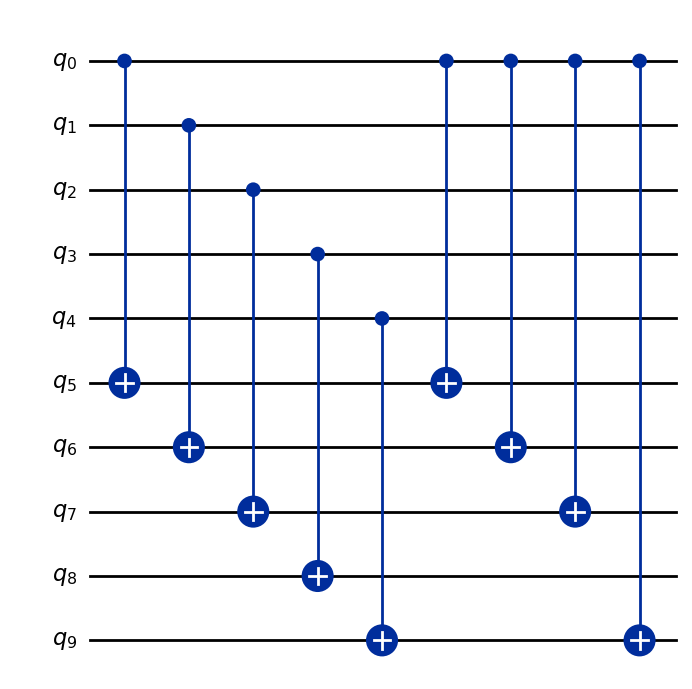

In [7]:
#Please change these values. 
# Reference used: https://physlab.org/wp-content/uploads/2023/05/Simon_22120014_Fin.pdf
bs = '10111'
n = len(bs)

simon_oracle1 = QuantumCircuit(2*n) 

for i in range(n):
    simon_oracle1.cx(i, n+i)
    # add cnot gate first to second. transfering info

k = 0 

for i in range(n-1, -1, -1):
    # reverse counting. 
    if bs[i] == '1':
        #As soon as you get a hit for '1' in range n
        #loop again over n number 
        # if you see 1 at a cx gate from control = 0, target m whereever there is 1 in string.
        m = n
        for j in range(n-1, -1, -1):
            print(j,i)
            if bs[j]=='1':
                simon_oracle1.cx(k,m)
            m+=1
        break
    k+=1

simon_oracle1.draw('mpl')



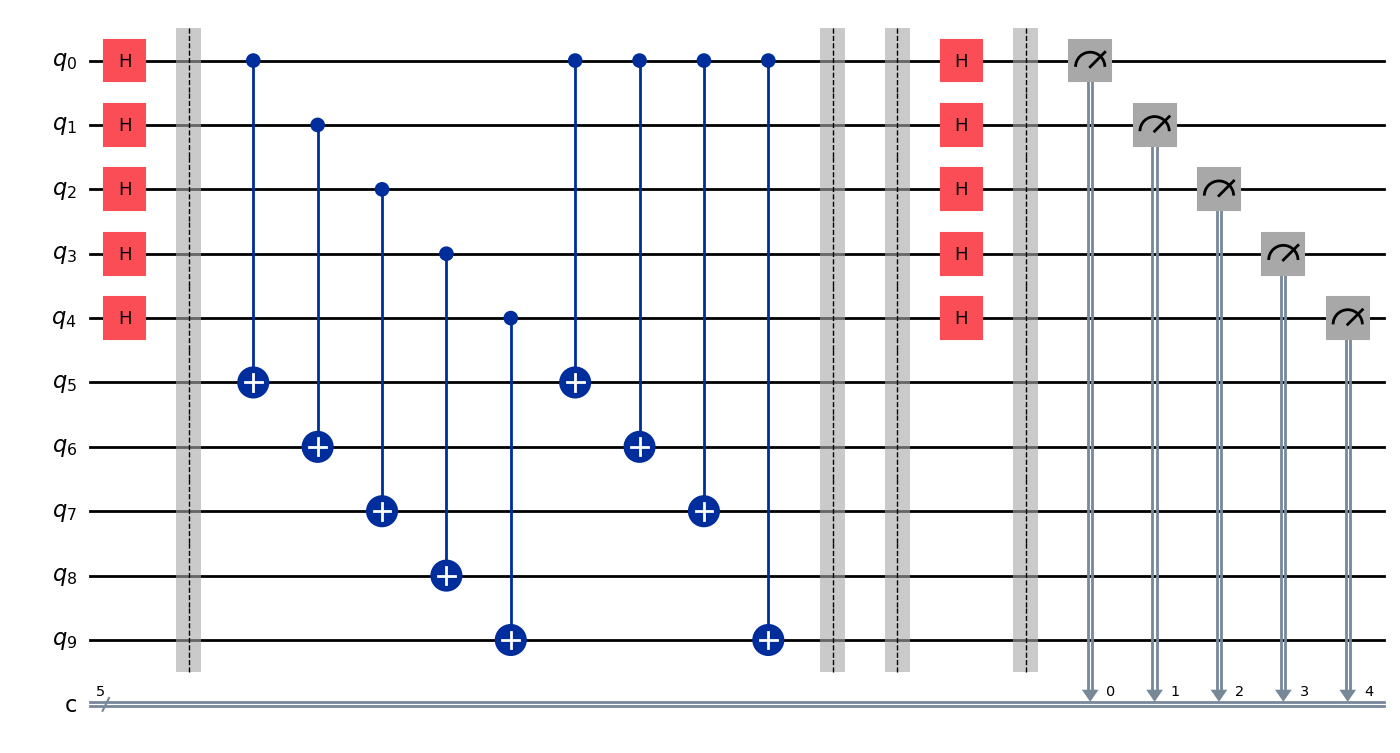

In [8]:

simon = QuantumCircuit(2*n, n) 
#because we only need to read first n qubits 

for qubit in range(n):
    simon.h(qubit)

simon.barrier()

# Add oracle
simon1 = simon.compose(simon_oracle1, inplace=True)

simon.barrier() 

simon.barrier()


# Repeat H-gates
for qubit in range(n):
    simon.h(qubit)
simon.barrier()

# Measuring 1st 4 qubits 
for i in range(n):
    simon.measure(i,i)

simon.draw('mpl')





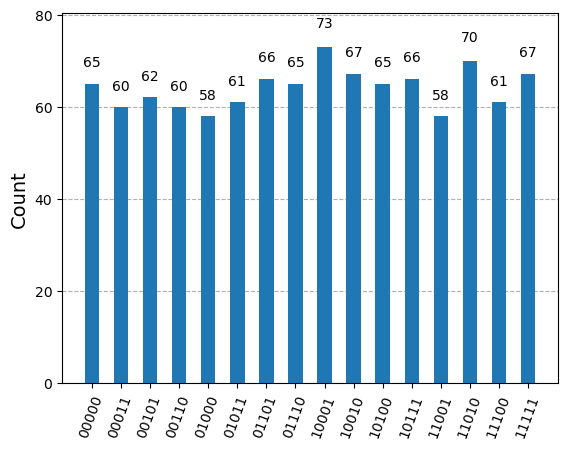

Orthogonal set is:  ['10110', '00101', '10100', '00000', '11101', '00111', '01011', '11010', '01001', '11000', '10001', '00010', '01110', '10011', '01100', '11111']
Secret string found is:  10111


In [9]:
#implementation oracle. 
backend = AerSimulator(method = 'automatic', precision = 'single')
result = backend.run(simon).result() 
counts = result.get_counts()
display(plot_histogram(counts))


# We just need to solve the output results using linear algebra. 
# By gaussian elimination, galois library. 
# Or by brute forcing the s string. this can be done by generating all
# possibillities and checking dot product of each of the generated strings 
# with all z/y (output values) 
# The string which is orthogonal to all the y's is the secret strings S.


def stringDotProduct(str1, str2):
    result = 0
    for i in range(len(str1)):
        if (str1[i] == '1' and str2[i] == '1'):
            result += 1
    return (result%2)

orthogonal_set = []
for bitstring in counts.keys():
    reversed_bitstring = bitstring[::-1]
    first_n_elements = reversed_bitstring[0:n]
    # we get only first the n qubit values like from 0011 we get 00. 
    # note that this is after reversing. so before it would 1100 
    # after reversing its 0011 and then we get 00 from it. that's equal to z string
    # We do not want repeated values so only getting unique values
    if not( first_n_elements in orthogonal_set):
        orthogonal_set.append( first_n_elements)

print("Orthogonal set is: ",orthogonal_set)

# This is basically the same as saying you have less equations than unknowns.
if len(orthogonal_set) < len(orthogonal_set[0]):
    print("You need more strings!!!!!!!!")
    

# We define n to be the length of the strings. 
# We assume all of them to be of the same length.
n = len(orthogonal_set[0])

# This basically goes over all possible integer values from 0 all the way
# up to 2**n-1, the biggest number you can represent with n bits. For each
# value, it converts it to binary form, padding the beginning with 0s to 
# make its length n.
setOfAllPossibleBitStrings = [ format(b, '0'+str(n)+'b') for b in range(2**n) ]

# Using brute force method
# the algorithm just goes over all possible bitstrings and checks
# whether that particular string is orthogonal to each bitstring in the orthogonal_set.
# If it is, it equates that to the result.
# One important thing to notice is 000..0 bitstring is always orthonogal to any set
# of bitstrings, and since setOfAllPossibleBitStrings contains the bitstrings in increasing
# order, we return the latest one as our result.
result = ""
for string in setOfAllPossibleBitStrings:
    orthogonal_counter = 0
    for orthoElement in orthogonal_set:
        if (stringDotProduct(string, orthoElement) == 0):
            orthogonal_counter += 1

    if (orthogonal_counter == len(orthogonal_set)):
        result = string
print("Secret string found is: ",result[::-1])